In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-03-30 17:39:04.305631: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 17:39:04.366545: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-30 17:39:04.398600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743370744.455718     343 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743370744.466433     343 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-30 17:39:04.554449: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from hyperion_utils import *
from sklearn.decomposition import PCA

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [4]:
myTreatmentColumn = 'groupe'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'CPC12', 
                                                                         aTreatmentColumn = myTreatmentColumn,     
                                                                         aSkipTemp = False) 

In [5]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )

In [6]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=10)
    myImputer.set_output(transform="pandas")
    # myCovariates = getCovariatePreprocessor(['bin__' + myTreatmentColumn])
    # myImputer.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor), ('imputer', myImputer)]

In [7]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [8]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(32, activation='relu'), 
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


2025-03-30 17:39:10.150916: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=15, batch_size=32, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7246 - loss: 0.5390 - roc_auc: 0.4390 - val_accuracy: 0.9200 - val_loss: 0.2982 - val_roc_auc: 0.5665
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9237 - loss: 0.3126 - roc_auc: 0.5277 - val_accuracy: 0.9200 - val_loss: 0.2713 - val_roc_auc: 0.6444
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9313 - loss: 0.2515 - roc_auc: 0.6720 - val_accuracy: 0.9200 - val_loss: 0.2629 - val_roc_auc: 0.6970
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9269 - loss: 0.2714 - roc_auc: 0.6624 - val_accuracy: 0.9200 - val_loss: 0.2544 - val_roc_auc: 0.7265
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9331 - loss: 0.2482 - roc_auc: 0.6884 - val_accuracy: 0.9200 - val_loss: 0.2481 - val_roc_auc: 0.7571
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9325 - loss: 0.2072 - roc_auc: 0.8037 - val_accuracy: 0.9200 - val_loss: 0.2427 - val_roc_auc: 0.7835
Epo

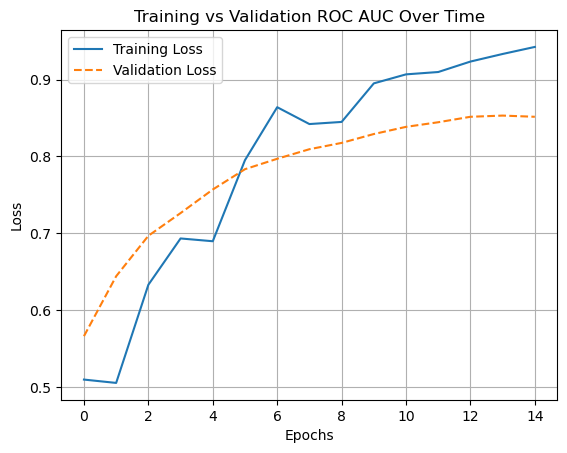

In [10]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
ROC AUC Score: 0.8536


In [12]:
y_pred_probs.T[0, :]

array([4.22115577e-03, 2.76434477e-02, 4.89574634e-02, 1.82885230e-01,
       1.96909159e-03, 3.31040360e-02, 5.84437000e-03, 1.12580908e-02,
       2.35135525e-01, 6.18833154e-02, 2.24000067e-02, 8.23106384e-04,
       1.39774978e-01, 3.69890360e-03, 1.28751658e-02, 3.15344445e-02,
       6.44754246e-02, 1.18496597e-01, 8.10505450e-03, 5.62764890e-03,
       5.73328100e-02, 4.58652049e-01, 2.93162512e-03, 5.26312515e-02,
       2.22195052e-02, 1.39871031e-01, 9.50978661e-04, 2.01496243e-01,
       1.58053078e-02, 6.02732319e-03, 7.33462051e-02, 7.96101838e-02,
       4.60340176e-04, 1.48396492e-02, 1.61652314e-03, 1.72868464e-03,
       3.79761652e-04, 5.39636053e-02, 1.94180361e-03, 2.07893569e-02,
       8.36906135e-02, 5.39535768e-02, 6.98724820e-04, 7.21477345e-02,
       1.21113965e-02, 1.85111225e-01, 2.19572708e-02, 9.66913439e-03,
       2.28110864e-03, 1.06205873e-01, 3.18126343e-02, 4.57621217e-02,
       6.79140503e-04, 2.16428842e-03, 4.89896312e-02, 1.89660359e-02,
      

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Optimization terminated successfully.
         Current function value: 0.263001
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.262240
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 0.6178317694330531
p-value: 0.734242528447232
Degress of freedom: 2.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  406
Model:                          Logit   Df Residuals:                      402
Method:                           MLE   Df Model:                            3
Date:                Sun, 30 Mar 2025   Pseudo R-squ.:                 0.02511
Time:                        17:39:34   Log-Likelihood:                -106.78
converged:                       True   LL-Null:                       -109.53
Covariance Type:      

0.734242528447232

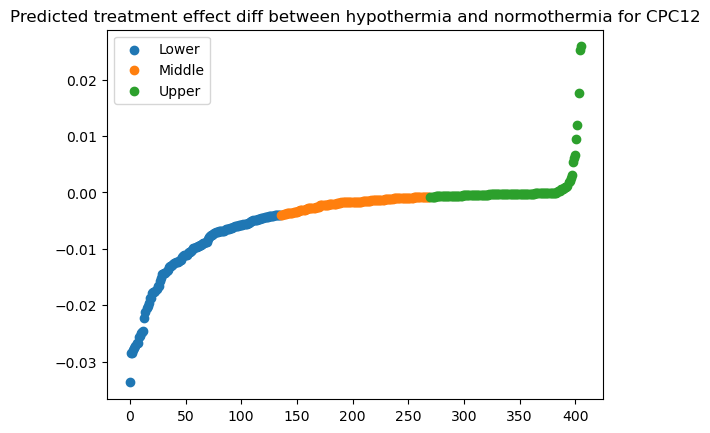

In [15]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'CPC12', aGroup = 'bin__groupe', aUseNeuralNetwork = True, aByGroup = False)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Optimization terminated successfully.
         Current function value: 0.274583
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.274260
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 0.11278136073011069
p-value: 0.7369995467194708
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  175
Model:                          Logit   Df Residuals:                      172
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Mar 2025   Pseudo R-squ.:                 0.01502
Time:                        17:39:34   Log-Likelihood:                -48.052
converged:                       True   LL-Null:                       -48.785
Covariance Type:        

0.7369995467194708

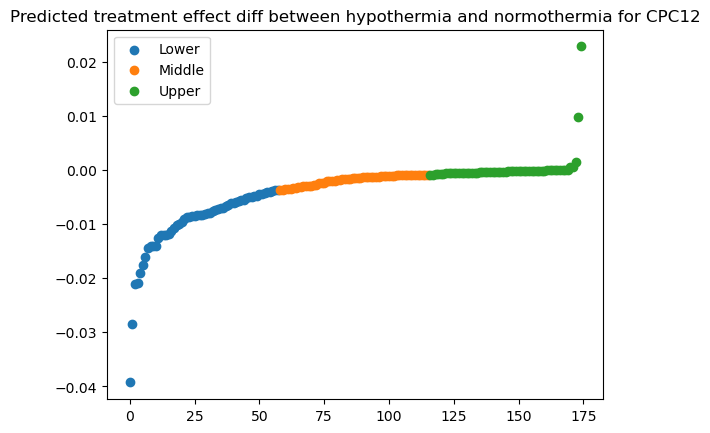

In [16]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'CPC12', aGroup = 'bin__groupe', aUseNeuralNetwork = True, aByGroup = False)

In [87]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

NameError: name 'myNewDf' is not defined